In [148]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np
import matplotlib.dates as mdates
import yaml

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive, utilities

In [149]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)
plotting_style = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle'

# 1. Choose a glider mission and load the dataset (OG1 format)

In [150]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=5, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', options=('11/07 (dives: 454)',), value='11/07 (dives: 454)')

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/102/20071113/


In [151]:
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

In [159]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')
ds_binned = xr.open_dataset(mission_path + '/dissipation_binned.nc')
ds = remove_spikes(ds, ['SIGMA_T','SIGTHETA','SIGMA_T'], window=20, threshold=0.02)

In [160]:
interactive.interactive_mld_profile(ds)

Output()

In [156]:
import pandas as pd
def remove_spikes(ds, vars, window=20, threshold=0.03):
    for var in vars:
        arr = ds[var].values
        s = pd.Series(arr)

        # Compute rolling mean excluding the current point (centered)
        roll_mean = s.rolling(window=window, center=True, min_periods=1).mean()

        # To exclude the self-value, recompute with one fewer point:
        # (optional — often negligible if window is large)
        # roll_mean_adj = (roll_mean * window - s) / (window - 1)

        # Mark points that deviate too far from local mean
        mask = np.abs(s - roll_mean) > threshold
        s[mask] = np.nan

        ds[var].values = s.values
    return ds

In [168]:
ds = remove_spikes(ds, ['SIGMA_1','SIGTHETA','SIGMA_T'], window=20, threshold=0.01)
mld_CR = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-3, use_bins=True, binning = 5)
mld_threshold = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)

No density values below reference depth 10 m exceed the threshold.
No density values below reference depth 10 m exceed the threshold.
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No density values below reference depth 10 m exceed the threshold.
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below 

# 2. Calculate dissipation for the glider mission

### Define cut-off length and window size and calculate the binned profiles of LEM dissipation 

In [71]:
### try out different filter lengths and so on
cut_off = 400 #seconds
window_size = 130 #seconds
ds_filtered = tools.highpass_butterworth_time(ds, 'VERTICAL_WATER_VELOCITY', cutoff_period=cut_off, order=4, max_interval=60)
ds_filtered = tools.add_velocity_scale(ds_filtered,window_size_seconds=window_size)
vars_to_bin = ['VERTICAL_WATER_VELOCITY','DEPTH','PRES','TEMP','PSAL',
               'LONGITUDE','LATITUDE','VERTICAL_WATER_VELOCITY_HP',
               'VELOCITY_SCALE','VELOCITY_SCALE_2_LOG','SIGMA_T']
ds_binned = utilities.bin_all_profiles(ds_filtered,vars = vars_to_bin, binning = None, dim = 'DEPTH',max_interval=20, agg='median')
ds_binned = tools.add_adiabatic_sorted_N2(ds_binned, plev=20) 
ds_binned = tools.add_unsorted_N2(ds_binned)

Filtering VERTICAL_WATER_VELOCITY:   6%|▋         | 56/890 [00:02<00:33, 25.08it/s]


KeyboardInterrupt: 

In [113]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.ticker as mticker

bathymetry = xr.open_dataset("/Users/tillmoritz/Desktop/Master_thesis/Data/Bathymetry/GEBCO_2024_IFR.nc")
plotting_style = "/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle"
def get_bathymetry_levels(bath, level_spacing=250):
        """
        This function computes the bathymetry levels for a given bathymetry dataset.

        Parameters
        ----------
        bath: xarray.Dataset
            Bathymetry dataset with 'elevation' variable.
        level_spacing: int, optional
            The spacing between contour levels. Default is 250 m.

        Returns
        -------
        levels: numpy.ndarray
            An array of bathymetry levels.
        contour_levels: numpy.ndarray
            An array of contour levels.
        max_level: int
            The maximum bathymetry level.
        """
        max_depth = np.max(bath.elevation.values)  # Depths are negative
        max_level = level_spacing * (np.round(max_depth / level_spacing) + 1)
        levels = np.arange(0, max_level, level_spacing)
        contour_levels = levels[::2]  # Every second level
        return levels, contour_levels, max_level

def get_var_styles(var_list):
    """Return line, marker, and color styles for a list of variables."""
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', '*', 'x', '^']
    colors = ['tab:blue', 'tab:orange', 'tab:gray', 'tab:cyan']
    return (
        {var: linestyles[i % len(linestyles)] for i, var in enumerate(var_list)},
        {var: markers[i % len(markers)] for i, var in enumerate(var_list)},
        {var: colors[i % len(colors)] for i, var in enumerate(var_list)}
    )

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_glider_track(ds, mean_after="Profile", ax=None, **kw):
    """
    Plot glider track colored by profile number with bathymetry background.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with LATITUDE, LONGITUDE, PROFILE_NUMBER.
    mean_after : {"Profile", "Cast", "None"}, default="Profile"
        Whether to average lat/lon per profile, per cast, or use raw values.
    ax : matplotlib.axes.Axes, optional
        Existing Cartopy map axis to plot on.
    **kw : dict
        Additional keyword arguments for ax.scatter().

    Returns
    -------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    """

    map_kw = ccrs.PlateCarree()

    with plt.style.context(plotting_style):
        # Create figure/axis if not provided
        if ax is None:
            fig, ax = plt.subplots(subplot_kw={"projection": map_kw}, figsize=(8, 6))
        else:
            fig = ax.get_figure()
            # If provided axis has no Cartopy projection, replace it
            if not hasattr(ax, 'projection'):
                # Remember position and remove old one
                pos = ax.get_position()
                ax.remove()
                ax = fig.add_axes(pos, projection=ccrs.PlateCarree())

        # Define map bounds
        lon_min, lon_max = -15, -6
        lat_min, lat_max = 61, 65
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=map_kw)
        ax.set_aspect('auto')

        # --- Bathymetry background ---
        bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        levels, contour_levels, max_level = get_bathymetry_levels(bath)
        base_cmap = plt.get_cmap("Greys")
        cmap_bath = mcolors.LinearSegmentedColormap.from_list(
            "light_greys", base_cmap(np.linspace(0.0, 0.5, len(levels)))
            )

        # Make a discrete normalization based on your levels
        norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_bath.N)

        # Plot with levels + colormap
        pcm = ax.pcolormesh(
            bath.lon, bath.lat, abs(bath.elevation.values),
            cmap=cmap_bath, norm=norm, transform=ccrs.PlateCarree(), zorder=1
        )
        #ax.contour(
        #    bath.lon, bath.lat, abs(bath.elevation.values),
        #    levels=contour_levels, colors="black", linewidths=0.4,
        #    transform=map_kw, zorder=2
        #)

        # --- Glider track colored by profile number ---
        if mean_after == "Profile":
            latitudes = ds.LATITUDE.groupby(ds.PROFILE_NUMBER).mean().values
            longitudes = ds.LONGITUDE.groupby(ds.PROFILE_NUMBER).mean().values
            profiles = np.unique(ds.PROFILE_NUMBER.values)
        elif mean_after == "Cast":
            latitudes = ds.LATITUDE.groupby(ds.CAST).mean().values
            longitudes = ds.LONGITUDE.groupby(ds.CAST).mean().values
            profiles = ds.CAST.values
        else:
            latitudes = ds.LATITUDE.values
            longitudes = ds.LONGITUDE.values
            profiles = ds.PROFILE_NUMBER.values

        sc = ax.scatter(
            longitudes, latitudes,
            c=profiles, cmap="Reds", s=30, marker="o", edgecolor="k", linewidth=0.2,
            transform=map_kw, zorder=3, **kw
        )

        # --- Horizontal colorbar for profile number ---
        #cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.08, shrink=0.8)
        #cbar.set_label("Profile Number",fontsize=11)

        # --- Map features ---
        ax.add_feature(cfeature.LAND, color="gray", zorder=10)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

        # --- Labels & title ---
        #ax.set_xlabel("Longitude")
        #ax.set_ylabel("Latitude")
        #ax.set_title("Glider Track with Bathymetry (colored by Profile Number)")

        # --- Gridlines ---
        gl = ax.gridlines(draw_labels=True, color="gray", alpha=0.4, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator([-14, -12, -10, -8, -6])
        gl.ylocator = mticker.FixedLocator([61, 62, 63, 64, 65])

        return fig, ax

In [162]:
### calc also LEM
importlib.reload(plotting)
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)

### Extract the c value from the bg_yaml
Glider = ds_binned.attrs['Glider']
Mission = ds_binned.attrs['Mission']

c = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['c']
print(f'Using c = {c} from bg_dissipation.yaml for glider {Glider} mission {Mission}')
ds_binned = tools.LEM_dissipation(ds_binned,c = c)



Using c = 0.4 from bg_dissipation.yaml for glider 102 mission 20071113


In [163]:
### get depth_range and profile_range from yaml
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)
profile_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['profile_range']
depth_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['depth_range']

print(f'Profile Range: {profile_range}, Depth Range: {depth_range}')

Profile Range: [225, 375], Depth Range: [200, 400]


for glider, missions in bg_yaml.items():
    print(f"Glider: {glider}")
    for mission, params in missions.items():
        print(f"  Mission: {mission}")
        ds_binned = xr.open_dataset(destination_folder + '/'+ mission + '/dissipation_binned.nc')
        ds = xr.open_dataset(destination_folder + '/'+ mission + '/all_data_OG1.nc')
        ds = remove_spikes(ds, ['SIGMA_T','SIGTHETA','SIGMA_T'], window=20, threshold=0.03)

        mld_CR = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-3, use_bins=True, binning = 5)
        mld_threshold = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)

        profile_range = bg_yaml[glider][mission]['profile_range']
        depth_range = bg_yaml[glider][mission]['depth_range']

        levels = [-6.0,-6.4,-6.8,-7.2,-7.6,-8.0,-8.4,-8.8,-9.2,-9.6]
        #levels = True
        with plt.style.context(plotting_style):
            fig , ax = plt.subplots(1,2,figsize=(18,4), gridspec_kw={'width_ratios':[7,2]})
            fig_sec, ax_sec = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10,levels=levels, ax=ax[0], mld_df=mld_CR)
            ax_sec[0].set_ylim(1000,0)
            plot_glider_track(ds_binned, ax=ax[1])
            plt.subplots_adjust(wspace=-0.08)
            rect = plt.Rectangle((profile_range[0], depth_range[0]), profile_range[1]-profile_range[0], depth_range[1]-depth_range[0],
                                linewidth=3, edgecolor='black', facecolor='none', label='Dissipation background range')

            ax[0].add_patch(rect)
            ax[0].set_title(f'sg{ds_binned.Glider}/{ds_binned.Mission}')
            fig.savefig(f"/Users/tillmoritz/Desktop/Thesis_resources/Sections/{ds_binned.Glider+ds_binned.Mission}section_dissipation_CR.png", dpi=300, bbox_inches='tight')

        with plt.style.context(plotting_style):
            fig , ax = plt.subplots(1,2,figsize=(18,4), gridspec_kw={'width_ratios':[7,2]})
            fig_sec, ax_sec = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10,levels=levels, ax=ax[0], mld_df=mld_threshold)
            ax_sec[0].set_ylim(1000,0)
            plot_glider_track(ds_binned, ax=ax[1])
            plt.subplots_adjust(wspace=-0.08)
            rect = plt.Rectangle((profile_range[0], depth_range[0]), profile_range[1]-profile_range[0], depth_range[1]-depth_range[0],
                                linewidth=3, edgecolor='black', facecolor='none', label='Dissipation background range')

            ax[0].add_patch(rect)
            ax[0].set_title(f'sg{ds_binned.Glider}/{ds_binned.Mission}')
            fig.savefig(f"/Users/tillmoritz/Desktop/Thesis_resources/Sections/{ds_binned.Glider+ds_binned.Mission}section_dissipation.png", dpi=300, bbox_inches='tight')


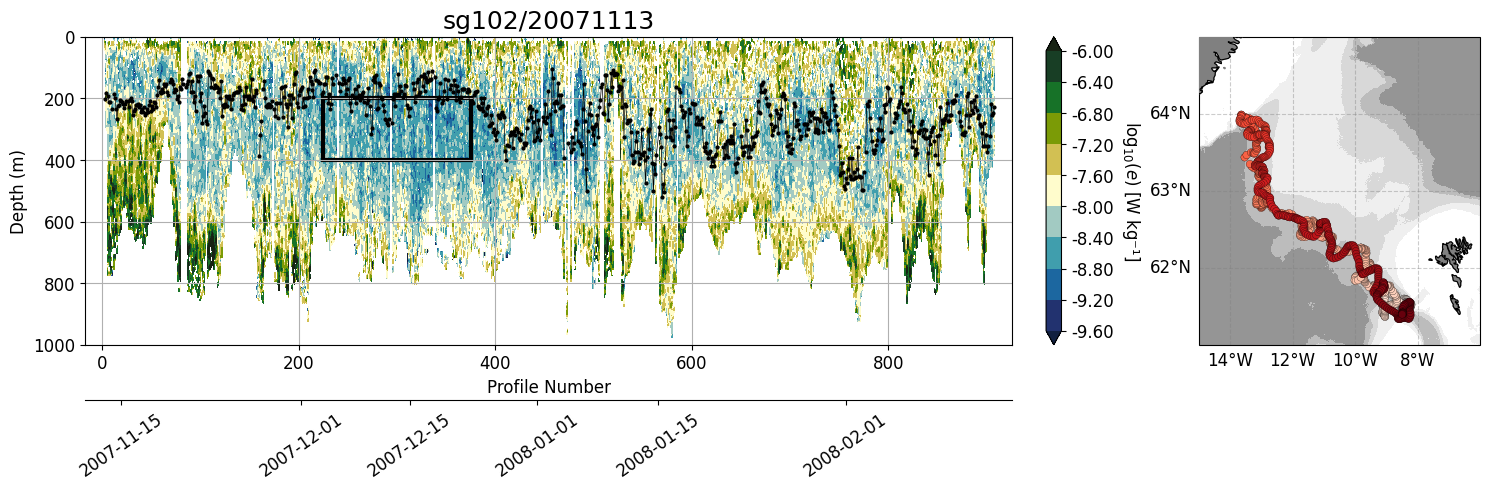

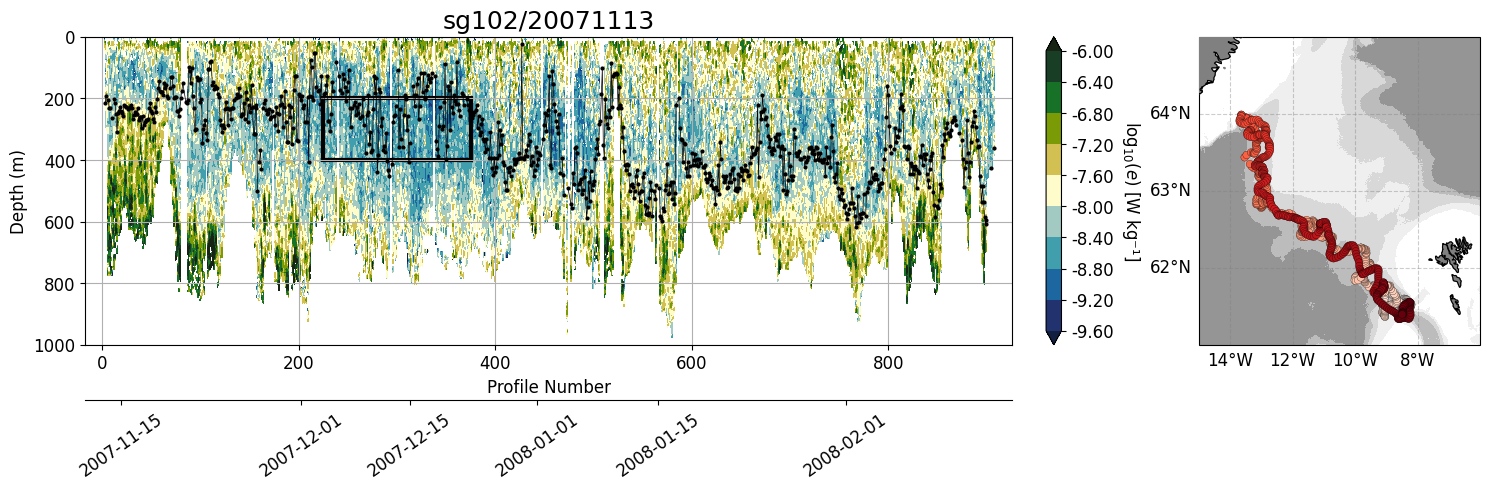

In [169]:
importlib.reload(plotting)
levels = [-6.0,-6.4,-6.8,-7.2,-7.6,-8.0,-8.4,-8.8,-9.2,-9.6]
with plt.style.context(plotting_style):
    fig , ax = plt.subplots(1,2,figsize=(18,4), gridspec_kw={'width_ratios':[7,2]})
    fig_sec, ax_sec = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10,levels=levels, ax=ax[0], mld_df=mld_CR)
    ax_sec[0].set_ylim(1000,0)
    plot_glider_track(ds_binned, ax=ax[1])
    plt.subplots_adjust(wspace=-0.08)
    rect = plt.Rectangle((profile_range[0], depth_range[0]), profile_range[1]-profile_range[0], depth_range[1]-depth_range[0],
                        linewidth=3, edgecolor='black', facecolor='none', label='Dissipation background range')

    ax[0].add_patch(rect)
    ax[0].set_title(f'sg{ds_binned.Glider}/{ds_binned.Mission}')
    fig.savefig(f"/Users/tillmoritz/Desktop/Thesis_resources/Sections/{ds_binned.Glider+ds_binned.Mission}section_dissipation_CR.png", dpi=300, bbox_inches='tight')

with plt.style.context(plotting_style):
    fig , ax = plt.subplots(1,2,figsize=(18,4), gridspec_kw={'width_ratios':[7,2]})
    fig_sec, ax_sec = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10,levels=levels, ax=ax[0], mld_df=mld_threshold)
    ax_sec[0].set_ylim(1000,0)
    plot_glider_track(ds_binned, ax=ax[1])
    plt.subplots_adjust(wspace=-0.08)
    rect = plt.Rectangle((profile_range[0], depth_range[0]), profile_range[1]-profile_range[0], depth_range[1]-depth_range[0],
                        linewidth=3, edgecolor='black', facecolor='none', label='Dissipation background range')

    ax[0].add_patch(rect)
    ax[0].set_title(f'sg{ds_binned.Glider}/{ds_binned.Mission}')
    fig.savefig(f"/Users/tillmoritz/Desktop/Thesis_resources/Sections/{ds_binned.Glider+ds_binned.Mission}section_dissipation.png", dpi=300, bbox_inches='tight')
plt.show()


start = 600
end = 700
fig, ax = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10,levels= True, start= start, end= end)

In [523]:
threshold = 1e-10
ds_binned['DISSIPATION_LEM'] = ds_binned['DISSIPATION_LEM'].where(ds_binned['DISSIPATION_LEM'] > threshold, np.nan)
ds_binned['DISSIPATION_LEM_LOG'] = np.log10(ds_binned['DISSIPATION_LEM'])

In [524]:
ds_binned.to_netcdf(mission_path + '/dissipation_binned.nc')

N = ds_binned['SORTED_N2']**0.5
e = ds_binned['DISSIPATION_LEM']
ds_binned['L_OZ'] = e**0.5*N**(-3/2)
ds_binned['L_OZ'].attrs['long_name'] = 'Ozmidov length scale'
ds_binned['L_OZ'].attrs['units'] = 'm'

ds_binned['L_OZ_LOG'] = np.log10(ds_binned['L_OZ'])

fig, ax = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG','L_OZ_LOG'], v_res=10, levels=True)
plotting.plot_histogram(ds_binned, vars=['L_OZ'], bins=100, log_scale=False, density=True)
fig, ax = plotting.plot_histogram(ds_binned, vars=['L_OZ_LOG'], bins=100, log_scale=False, density=True)

## add the max density of L_OZ_LOG histogram to the section plot
data = ds_binned['L_OZ_LOG'].values.flatten()
data = data[~np.isnan(data)]
counts, bin_edges = np.histogram(data, bins=100)
max_density_index = np.argmax(counts)
max_density_value = (bin_edges[max_density_index] + bin_edges[max_density_index + 1]) / 2
ax[0].axvline(max_density_value, color='r', linestyle='--', label='Max Density in meter: {:.2f}'.format(10**max_density_value))
ax[0].legend()



plt.show()

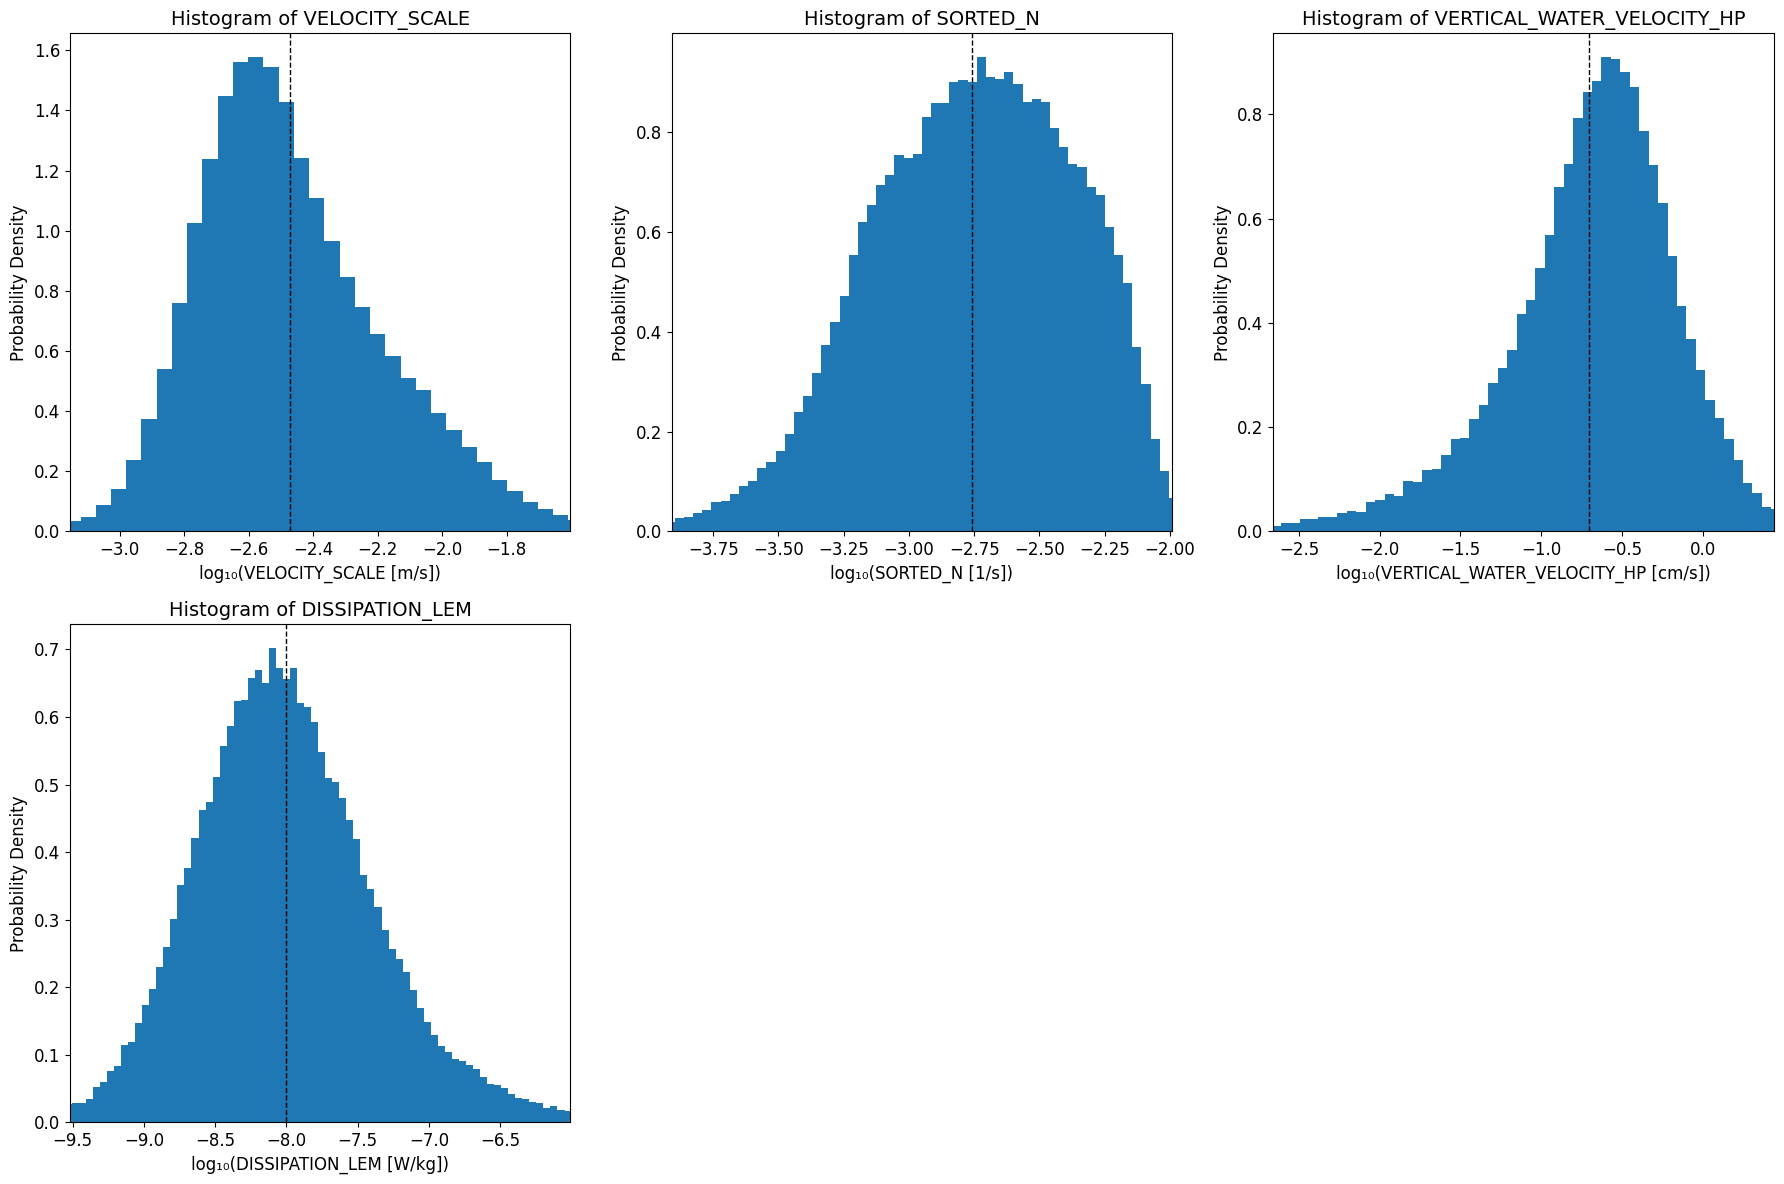

In [307]:
importlib.reload(plotting)
fig, axes = plotting.plot_histogram(ds_binned, vars=['VELOCITY_SCALE','SORTED_N','VERTICAL_WATER_VELOCITY_HP','DISSIPATION_LEM'], bins=100, log_scale=True, density=True)
plt.show()

In [423]:
### load sg005 mission 20080606 as it is the only mission verified using Microstructure profile
sg005_mission = destination_folder + '/005/20080606'
sg005_ds = xr.open_dataset(sg005_mission + '/dissipation_binned.nc')

In [424]:
importlib.reload(plotting)
def get_background_dissipation(ds, profile_range=[0, -1], depth_range=[200, 400], sg005_ds=None):
    """
    Calculate the background dissipation from the dataset and optionally compare with sg005_ds.
    
    Parameters:
    - ds: xarray Dataset
    - profile_range: List [start, end] of profile numbers
    - depth_range: List [min_depth, max_depth]
    - sg005_ds: Optional xarray Dataset to compare
    
    Returns:
    - Tuple: (background_sg005, ds_background) if sg005_ds provided, else (None, ds_background)
    """
    
    def cut_background(ds, profile_range, depth_range):
        return ds.where(
            (ds.PROFILE_NUMBER >= profile_range[0]) &
            (ds.PROFILE_NUMBER <= profile_range[1]) &
            (ds.DEPTH >= depth_range[0]) &
            (ds.DEPTH <= depth_range[1]),
            drop=True
        )

    def plot_hist(ax, ds, median=None, mean=None, color='blue'):
        figh, axh = plotting.plot_histogram(
            ds, vars=['DISSIPATION_LEM'], bins=50, log_scale=True, density=True,
            alpha=0.2, color=color, edgecolor='black', ax=ax
        )
        unit = utilities.get_unit(ds, 'DISSIPATION_LEM')
        if mean is not None:
            ax.axvline(np.log10(mean), color=color, linestyle='--', label=f'Mean = {mean:.2e} [{unit}]')
        if median is not None:
            ax.axvline(np.log10(median), color=color, linestyle=':', label=f'Median = {median:.2e} [{unit}]')
        ax.set_title(f'Background Dissipation Histogram of sg{ds.Glider +'/'+ ds.Mission} (c = {ds.c_epsilon})')
        ax.legend()
        return ax

    ds_background = cut_background(ds, profile_range, depth_range)
    mean_bg = np.nanmean(ds_background['DISSIPATION_LEM'].values)
    median_bg = np.nanmedian(ds_background['DISSIPATION_LEM'].values)

    background_sg005 = None

    mean_ratio, median_ratio, ratio_total = None, None, None

    if sg005_ds is None:
        # Just one histogram
        fig, ax = plt.subplots(figsize=(8, 5))
        plot_hist(ax, ds_background, median_bg, mean_bg, color='blue', label='Background')
    else:
        # Load ranges and cut sg005 dataset
        profile_range_005 = bg_yaml['sg005']['005/20080606']['profile_range']
        depth_range_005 = bg_yaml['sg005']['005/20080606']['depth_range']
        background_sg005 = cut_background(sg005_ds, profile_range_005, depth_range_005)

        mean_005 = np.nanmean(background_sg005['DISSIPATION_LEM'].values)
        median_005 = np.nanmedian(background_sg005['DISSIPATION_LEM'].values)

        # Create combined figure with 3 subplots
        fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

        # Subplot 1: original dataset
        axs[0].set_title(f'Background Dissipation Histogram of {ds.id.split("T")[0]} (c = {ds.c_epsilon})')
        plot_hist(axs[0], ds_background, median_bg, mean_bg, color='blue')

        # Subplot 2: sg005 dataset
        axs[1].set_title(f'Background Dissipation Histogram of {sg005_ds.id.split("T")[0]} (c = {sg005_ds.c_epsilon})')
        plot_hist(axs[1], background_sg005, median_005, mean_005, color='red')

        # Subplot 3: comparison
        plotting.plot_histogram(ds_background, vars=['DISSIPATION_LEM'], bins=50, log_scale=True, density=True,
                                 alpha=0.2, color='blue', edgecolor='darkblue', ax=axs[2])
        plotting.plot_histogram(background_sg005, vars=['DISSIPATION_LEM'], bins=50, log_scale=True, density=True,
                                 alpha=0.2, color='red', edgecolor='darkred', ax=axs[2])
        axs[2].set_title('Comparison of Background Dissipation Histograms')
        axs[2].legend(['sg' + ds_background.Glider + '/' + ds_background.Mission, 'sg005/20080606'])

        c_005 = bg_yaml['sg005']['005/20080606']['c']
        mean_ratio = mean_005 / mean_bg
        c_mean = c_005 * mean_ratio
        median_ratio = median_005 / median_bg
        c_median = c_005 * median_ratio
        ratio_total = (mean_ratio + median_ratio) / 2
        c_total = c_005 * ratio_total

        print(f'Mean ratio (sg005/Background): {mean_ratio:.3f}, c = {c_mean:.3f}')
        print(f'Median ratio (sg005/Background): {median_ratio:.3f}, c = {c_median:.3f}')
        print(f'Average ratio (sg005/Background): {ratio_total:.3f}, c = {c_total:.3f}')

    # Show section plot
    figs, section_axs = plotting.plot_section(ds_background, vars=['DISSIPATION_LEM_LOG'], v_res=2)
    plt.show()

    return mean_ratio, median_ratio, ratio_total


In [425]:
### get depth_range and profile_range from yaml
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)
profile_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['profile_range']
depth_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['depth_range']

print(f'Profile Range: {profile_range}, Depth Range: {depth_range}')

Profile Range: [413, 430], Depth Range: [200, 400]


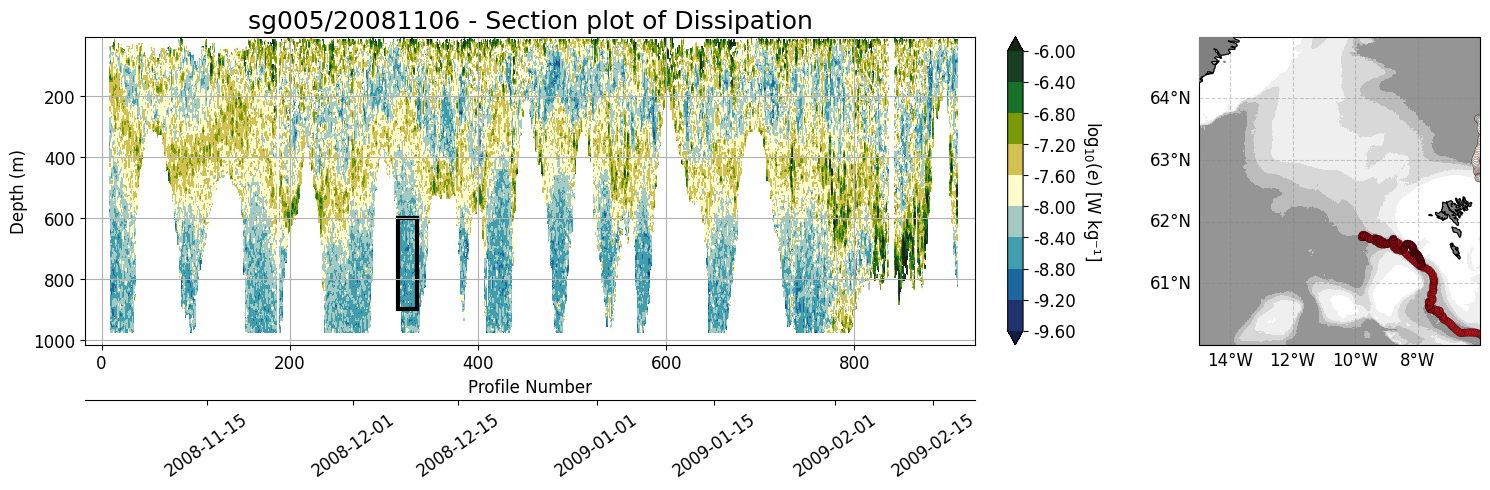

In [324]:
importlib.reload(plotting)
levels = [-6.0,-6.4,-6.8,-7.2,-7.6,-8.0,-8.4,-8.8,-9.2,-9.6]
#levels = True
with plt.style.context(plotting_style):
    fig , ax = plt.subplots(1,2,figsize=(18,4), gridspec_kw={'width_ratios':[7,2]})
    plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10,levels=levels, ax=ax[0])
    plot_glider_track(ds_binned, ax=ax[1])
    plt.subplots_adjust(wspace=0)
    rect = plt.Rectangle((profile_range[0], depth_range[0]), profile_range[1]-profile_range[0], depth_range[1]-depth_range[0],
                        linewidth=3, edgecolor='black', facecolor='none', label='Dissipation background range')

    ax[0].add_patch(rect)
    ax[0].set_title(f'sg{ds_binned.Glider}/{ds_binned.Mission} - Section plot of Dissipation')
    fig.savefig(f"/Users/tillmoritz/Desktop/Thesis_resources/Sections/{Glider+Mission}section_dissipation.png", dpi=300, bbox_inches='tight')
    #fig.savefig(mission_path + '/glider_track.png', dpi=300)
plt.show()

Mean ratio (sg005/Background): 0.644, c = 0.238
Median ratio (sg005/Background): 0.930, c = 0.344
Average ratio (sg005/Background): 0.787, c = 0.291


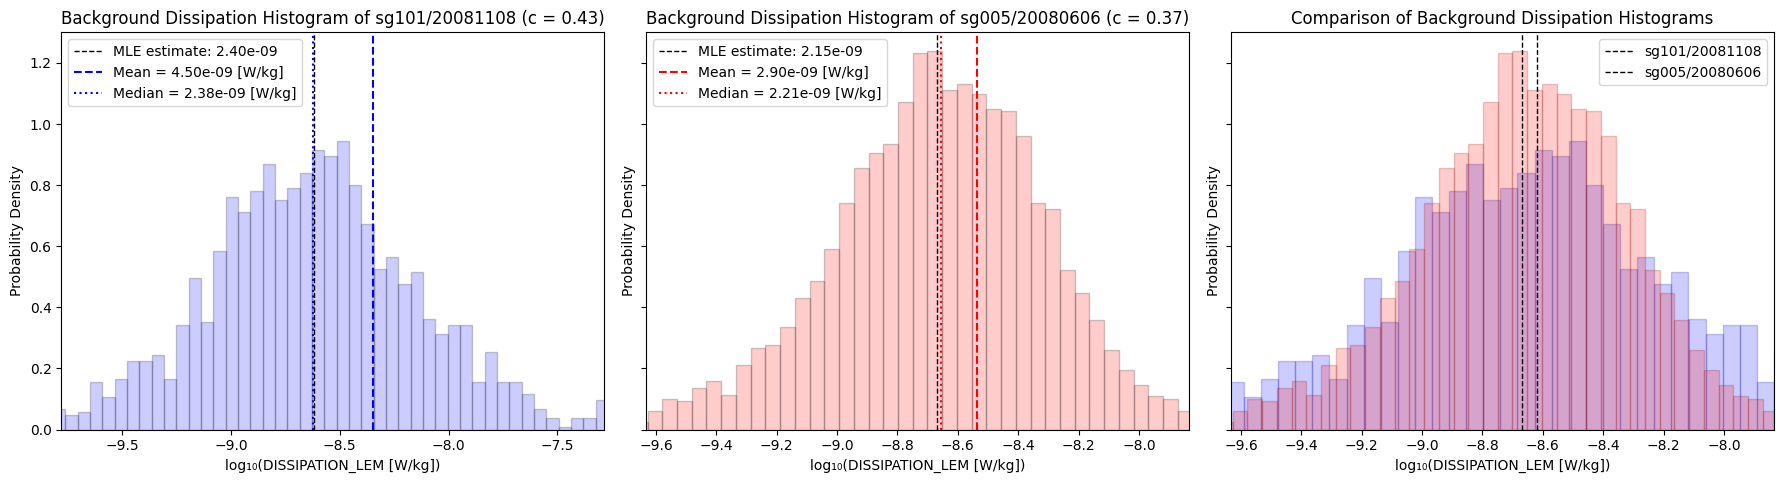

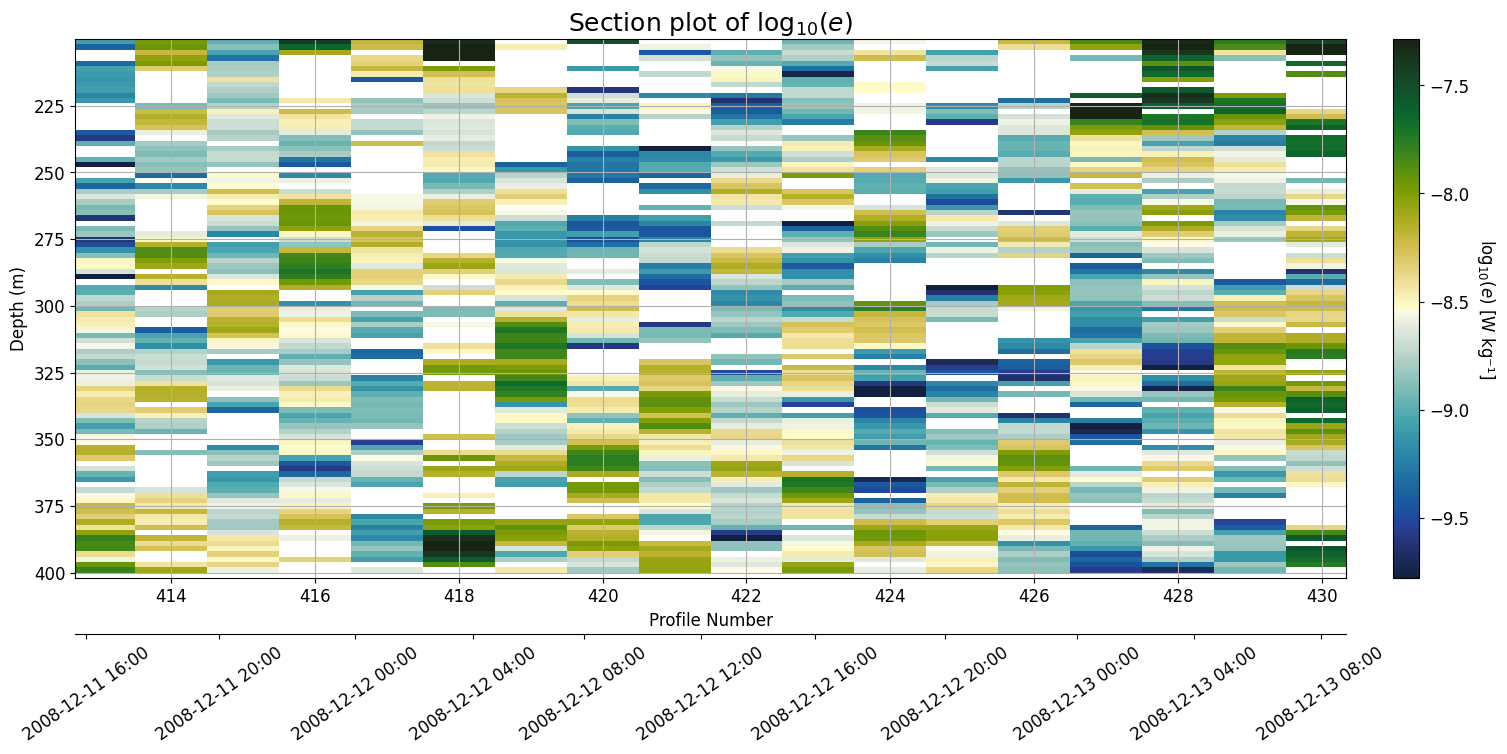

In [428]:
importlib.reload(plotting)
mean_ratio, median_ratio, ratio_total = get_background_dissipation(ds_binned, profile_range=profile_range, depth_range=depth_range, sg005_ds=sg005_ds)

In [557]:
### cut the profiles from 760 onwards if Glider is 101 and Mission is '20070609'
if ds_binned.Glider == '101' and ds_binned.Mission == '20070609':
    ds_binned = ds_binned.where(ds_binned.PROFILE_NUMBER < 760, drop=True)
    print('Cutting profiles from 760 onwards for Glider 101 and Mission 20070609')

### 2.X Save the binned data with dissipation information as dissipation_binned.nc

In [316]:
### save the ds_binned dataset and enable to overwrite it

ds_binned.to_netcdf(mission_path + '/dissipation_binned.nc')


In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=3, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', options=('11/07 (dives: 452)', '06/08 (dives: 421)', '06/09 (dives: 29…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/016/20071113/


In [22]:
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

In [23]:
ds_binned = xr.open_dataset(mission_path + '/dissipation_binned.nc')
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [27]:
mld_th = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)
#mld_CR = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-2, use_bins=True, binning = 5)
importlib.reload(utilities)
mld_ds = utilities.df_to_ds(mld_th,folder = selected_glider['mission'],glider_name= selected_glider['glider'])

No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data be

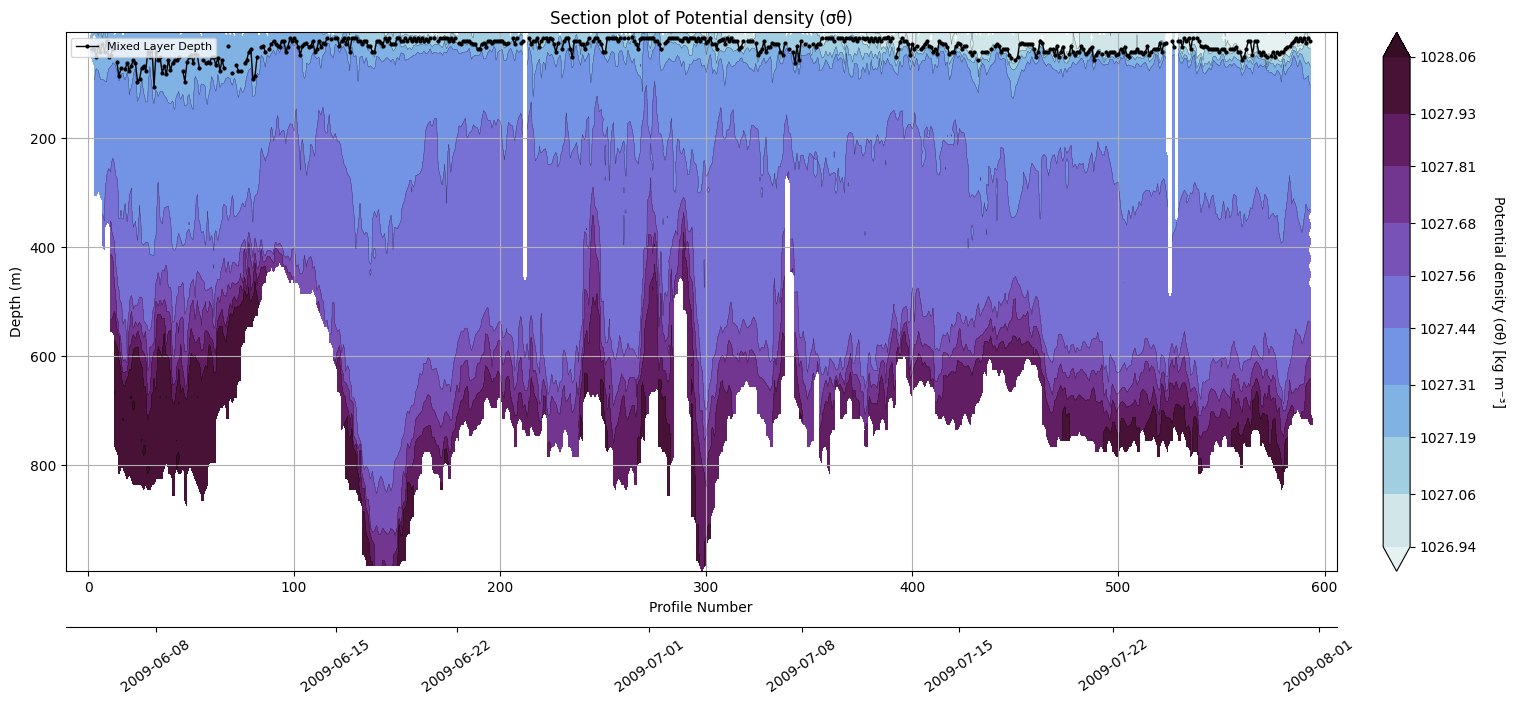

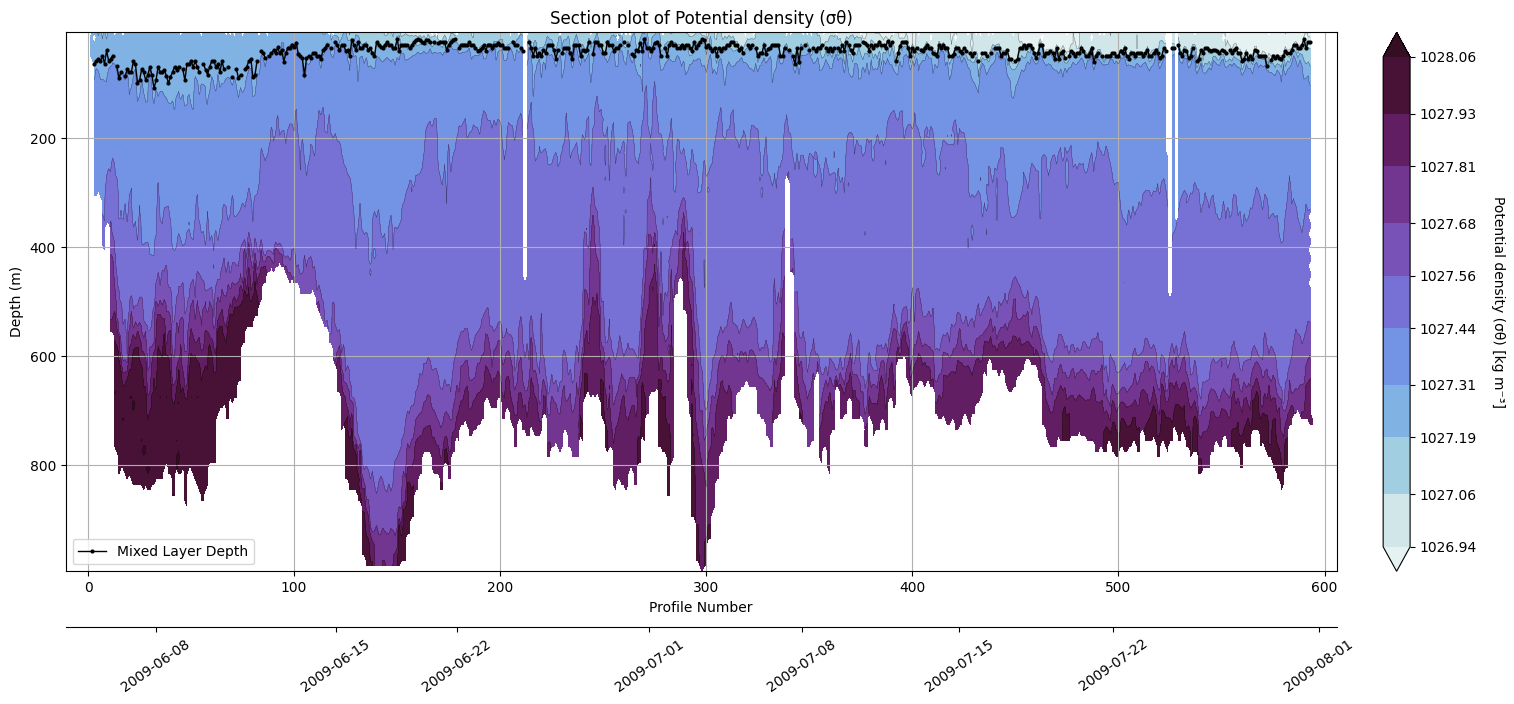

In [28]:
fig, ax = plotting.plot_section(ds, vars=['SIGTHETA'], v_res=10, mld_df = mld_th, levels=True)
fig, ax = plotting.plot_section(ds, vars=['SIGTHETA'], v_res=10, mld_df = mld_CR, levels=True)
ax[-1].legend(loc = 'lower left')
#fig.set_size_inches(16, 8)
plt.show()

### 3. Load ERA-5 data and compare to dissipation data 

In [101]:
ERA5_basepath = '/Users/tillmoritz/Desktop/Master_thesis/Data/ERA-5/'
ds_ERA5 = xr.open_dataset(ERA5_basepath + '/ERA5_all_winds_fluxes_waves.nc')

### 4. Finish the dissipation calculation

In [105]:
for glider, missions in bg_yaml.items():
    print(f"Glider: {glider}")
    for mission, params in missions.items():
        print(f"  Mission: {mission}")
        ds_binned = xr.open_dataset(destination_folder + '/'+ mission + '/dissipation_binned.nc')
        ds = xr.open_dataset(destination_folder + '/'+ mission + '/all_data_OG1.nc')
        ds = remove_spikes(ds, ['SIGMA_T','SIGTHETA','SIGMA_T'], window=20, threshold=0.03)

        mld_CR = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-3, use_bins=True, binning = 5)
        mld_CR = utilities.df_to_ds(mld_CR,folder = mission,glider_name= glider[-3:])
        mld_threshold = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)
        mld_th = utilities.df_to_ds(mld_threshold,folder = mission,glider_name= glider[-3:])

        datasets = {
            'mld_CR': mld_CR,
            'mld_th': mld_th,
        }

        for name, mld_ds in datasets.items():
            mld_ds = tools.mean_in_mld(ds, mld_ds, ['SIGTHETA','PSAL','TEMP'])
            mld_ds = tools.match_era5_to_mld(mld_ds, ds_ERA5, lon_range=0.25, lat_range=0.25,
                                            time_lag=None, time_range=None)
            mld_ds = tools.add_hs(mld_ds)
            
            H_S = mld_ds['H_S'].values
            MLD = mld_ds['MLD'].values
            mld_ds = tools.integrate_in_mld(ds_binned, mld_ds, ['DISSIPATION_LEM'],
                                            min_depth=H_S, max_depth=MLD)
            mld_ds_40 = tools.integrate_in_mld(ds_binned, mld_ds, ['DISSIPATION_LEM'],
                                            min_depth=40, max_depth=MLD)

            mld_ds = tools.dissipation_bouyancy_flux(mld_ds)
            mld_ds = tools.dissipation_wind_stress(mld_ds)

            # Save using the name
            if name == 'mld_CR':
                mld_ds.to_netcdf(f"{destination_folder}/{mission}/mld_CR.nc")
                mld_ds_40.to_netcdf(f"{destination_folder}/{mission}/mld_CR_Hs40m.nc")
            else:
                mld_ds.to_netcdf(f"{destination_folder}/{mission}/mld_threshold.nc")
                mld_ds_40.to_netcdf(f"{destination_folder}/{mission}/mld_threshold_Hs40m.nc")
            


        

Glider: sg005
  Mission: 005/20080606
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below reference depth 10 m
No depth data below

100%|██████████| 770/770 [00:09<00:00, 81.80it/s]


Computing mean for PSAL in MLD


100%|██████████| 770/770 [00:11<00:00, 69.08it/s]


Computing mean for TEMP in MLD


...

Matching ERA5 to MLD: 100%|██████████| 740/740 [00:03<00:00, 203.91it/s]


Calculating integral for DISSIPATION_LEM...


100%|██████████| 740/740 [00:11<00:00, 67.11it/s]


Calculating integral for DISSIPATION_LEM...


100%|██████████| 740/740 [00:10<00:00, 67.66it/s]


In [30]:
mld_ds = tools.mean_in_mld(ds, mld_ds, ['SIGTHETA','PSAL','TEMP'])

Computing mean for SIGTHETA in MLD


100%|██████████| 594/594 [00:04<00:00, 119.25it/s]


Computing mean for PSAL in MLD


100%|██████████| 594/594 [00:05<00:00, 110.06it/s]


Computing mean for TEMP in MLD


100%|██████████| 594/594 [00:05<00:00, 116.72it/s]


In [31]:
importlib.reload(tools)
mld_ds = tools.match_era5_to_mld(mld_ds, ds_ERA5,lon_range=0.25,lat_range=0.25,time_lag = None, time_range=None)

Matching ERA5 to MLD:   0%|          | 0/594 [00:00<?, ?it/s]

Matching ERA5 to MLD: 100%|██████████| 594/594 [00:03<00:00, 190.27it/s]


In [32]:
importlib.reload(tools)
mld_ds = tools.add_hs(mld_ds)

In [33]:
H_S = mld_ds['H_S'].values
MLD = mld_ds['MLD'].values
mld_ds = tools.integrate_in_mld(ds_binned, mld_ds, ['DISSIPATION_LEM'],min_depth=H_S, max_depth=MLD)

Calculating integral for DISSIPATION_LEM...


100%|██████████| 594/594 [00:06<00:00, 89.88it/s]


def add_epsilon_tau(ds, mld_ds):
    ds = ds.copy()
    epsilon_tau_z_all = []
    for i in tqdm(range(len(mld_ds['PROFILE_NUMBER']))):
        profile_number = mld_ds['PROFILE_NUMBER'].values[i]
        mld_depth = mld_ds['MLD'].values[i]
        tau = mld_ds['TAU'].values[i]
        rho = mld_ds['SIGTHETA_MEAN'].values[i]
        u_star = np.sqrt(tau/rho)

        # Extract variable and depth for current profile
        profile_mask = ds['PROFILE_NUMBER'] == profile_number
        profile = ds.where(profile_mask, drop=True)

        binned_depth = profile.DEPTH.values

        if np.isnan(mld_depth):
            epsilon_tau_z = np.full_like(binned_depth, np.nan)
            epsilon_tau_z_all.append(epsilon_tau_z)
            continue

        epsilon_tau_z = u_star**3/(0.4*binned_depth)
        epsilon_tau_z_all.append(epsilon_tau_z)
    epsilon_tau_z_all = np.concatenate(epsilon_tau_z_all)
    ds['EPSILON_TAU_Z'] = ('TIME', epsilon_tau_z_all)
    return ds

ds_binned = add_epsilon_tau(ds_binned,mld_ds)

fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(nrows=2,ncols=2,figsize= [10,6])
mld_ds['DISSIPATION_LEM_TOTAL'].plot(ax = ax1)
mld_ds['EPSILON_TAU_Z_TOTAL'].plot(ax = ax3)
mld_ds['EPSILON_TAU'].plot(ax = ax4)
plt.show()

In [34]:
importlib.reload(tools)
mld_ds = tools.dissipation_bouyancy_flux(mld_ds)
mld_ds = tools.dissipation_wind_stress(mld_ds)

In [36]:
#### save the mld_d's dataset
#mld_ds.to_netcdf(mission_path + '/dissipation_mld.nc')

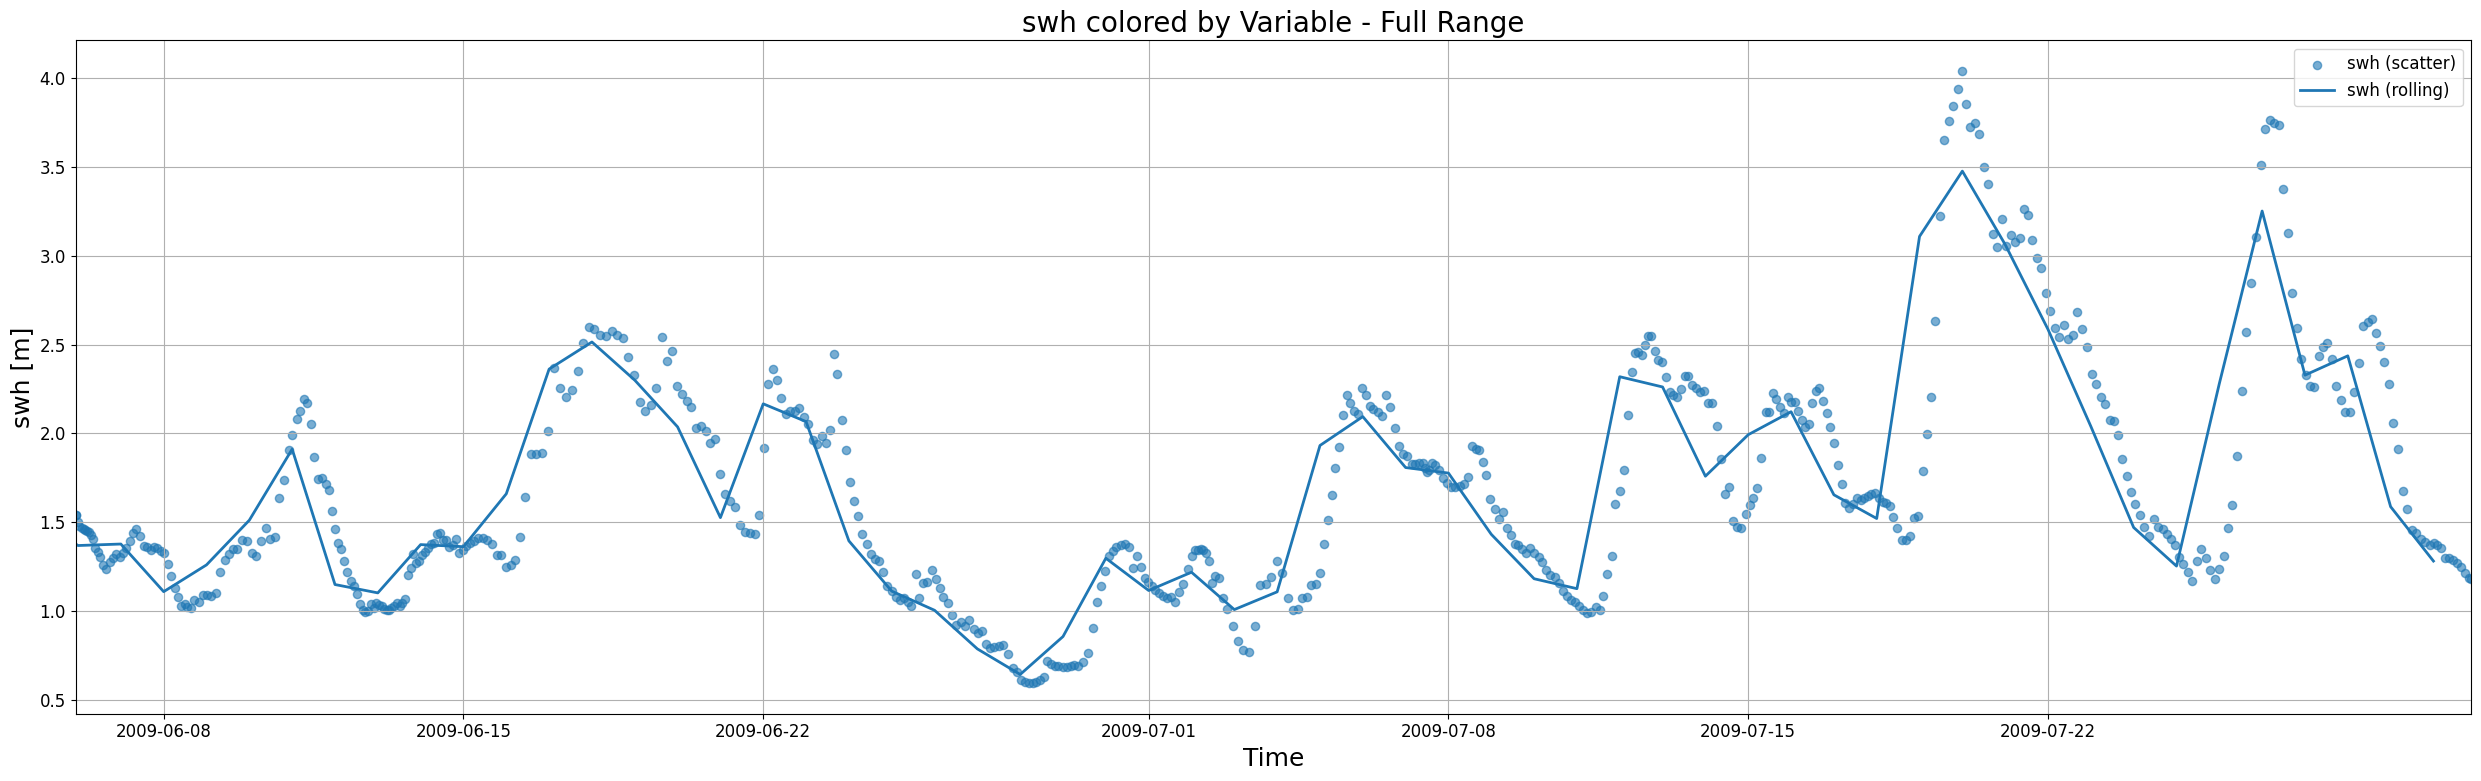

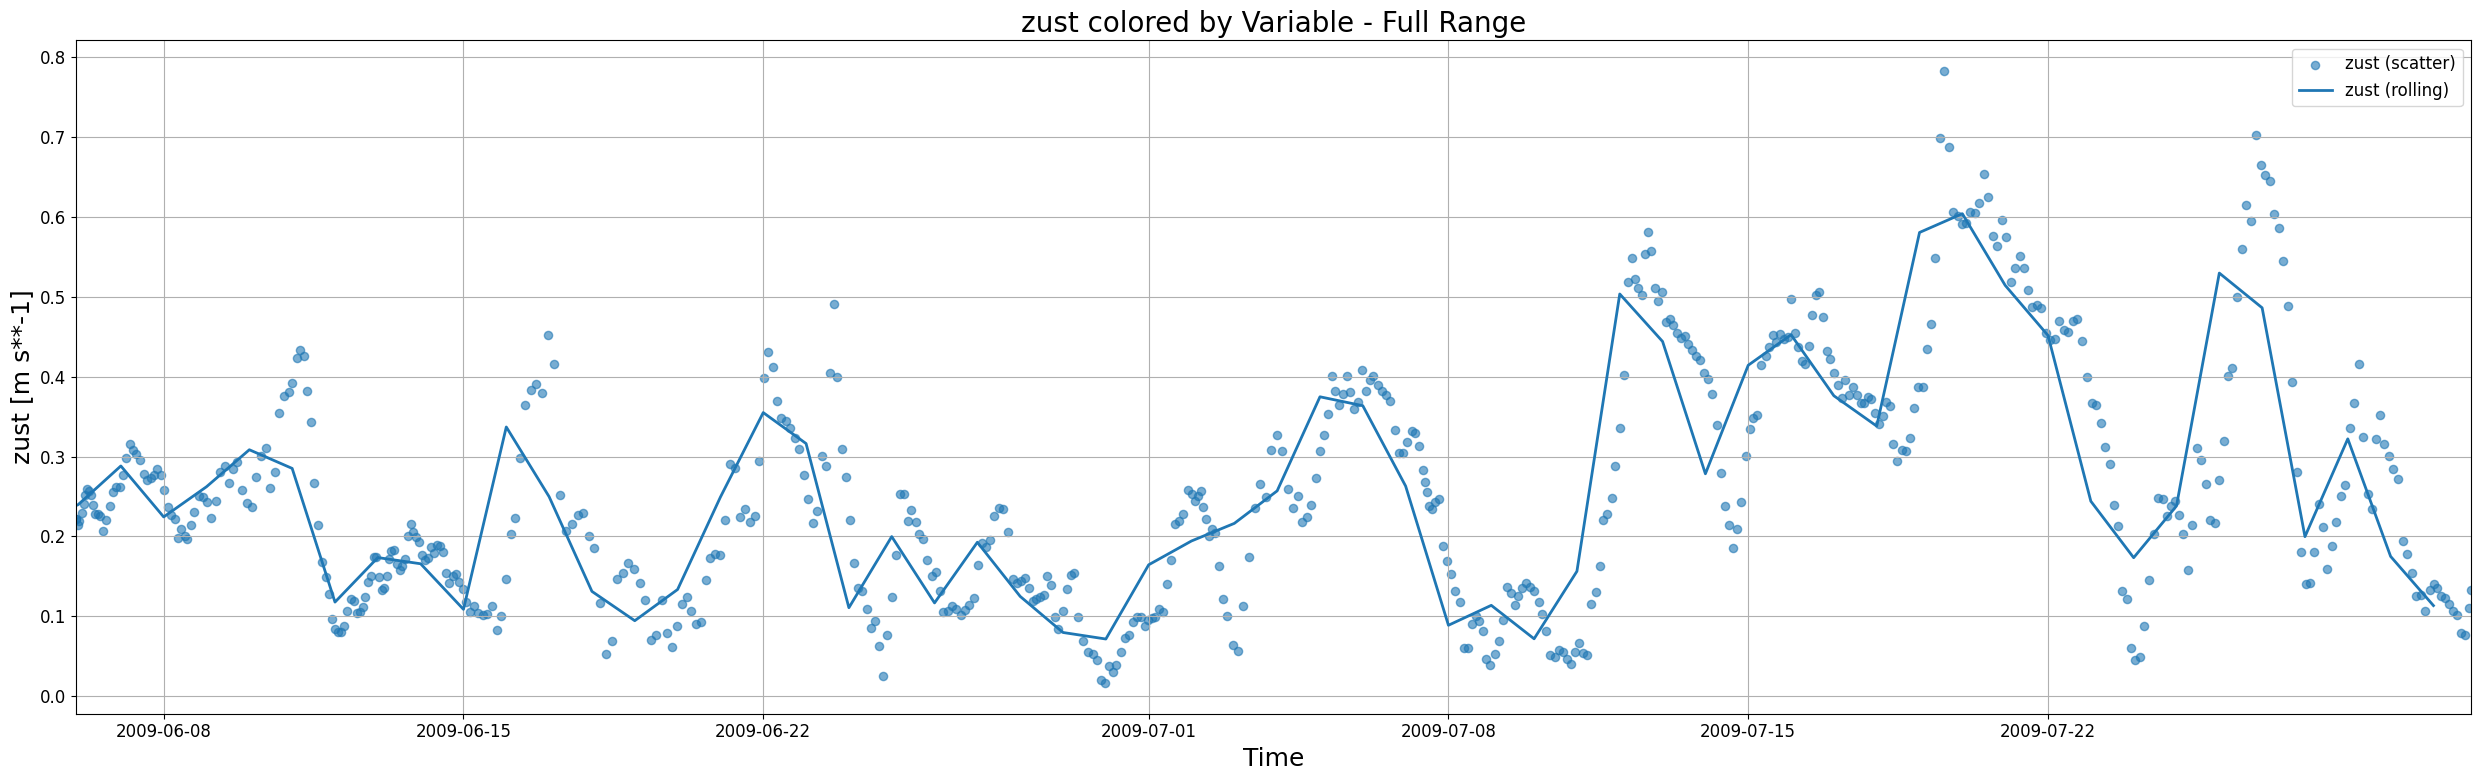

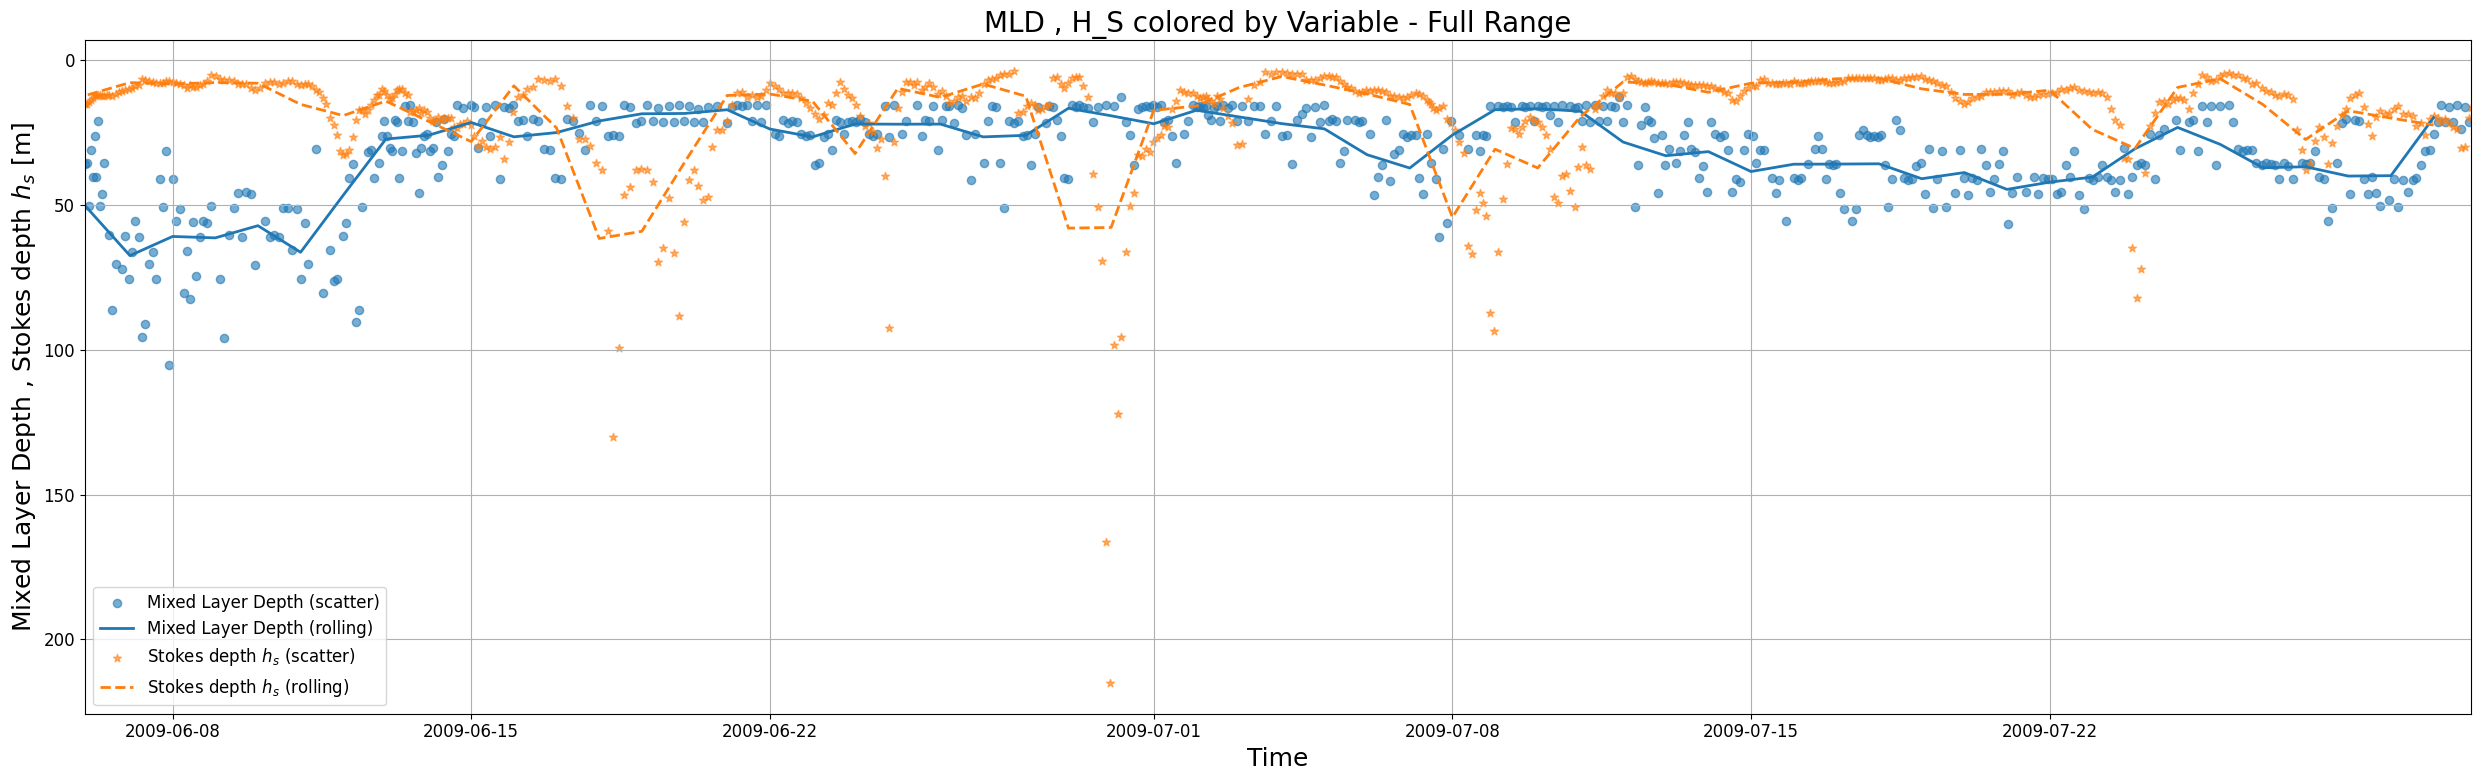

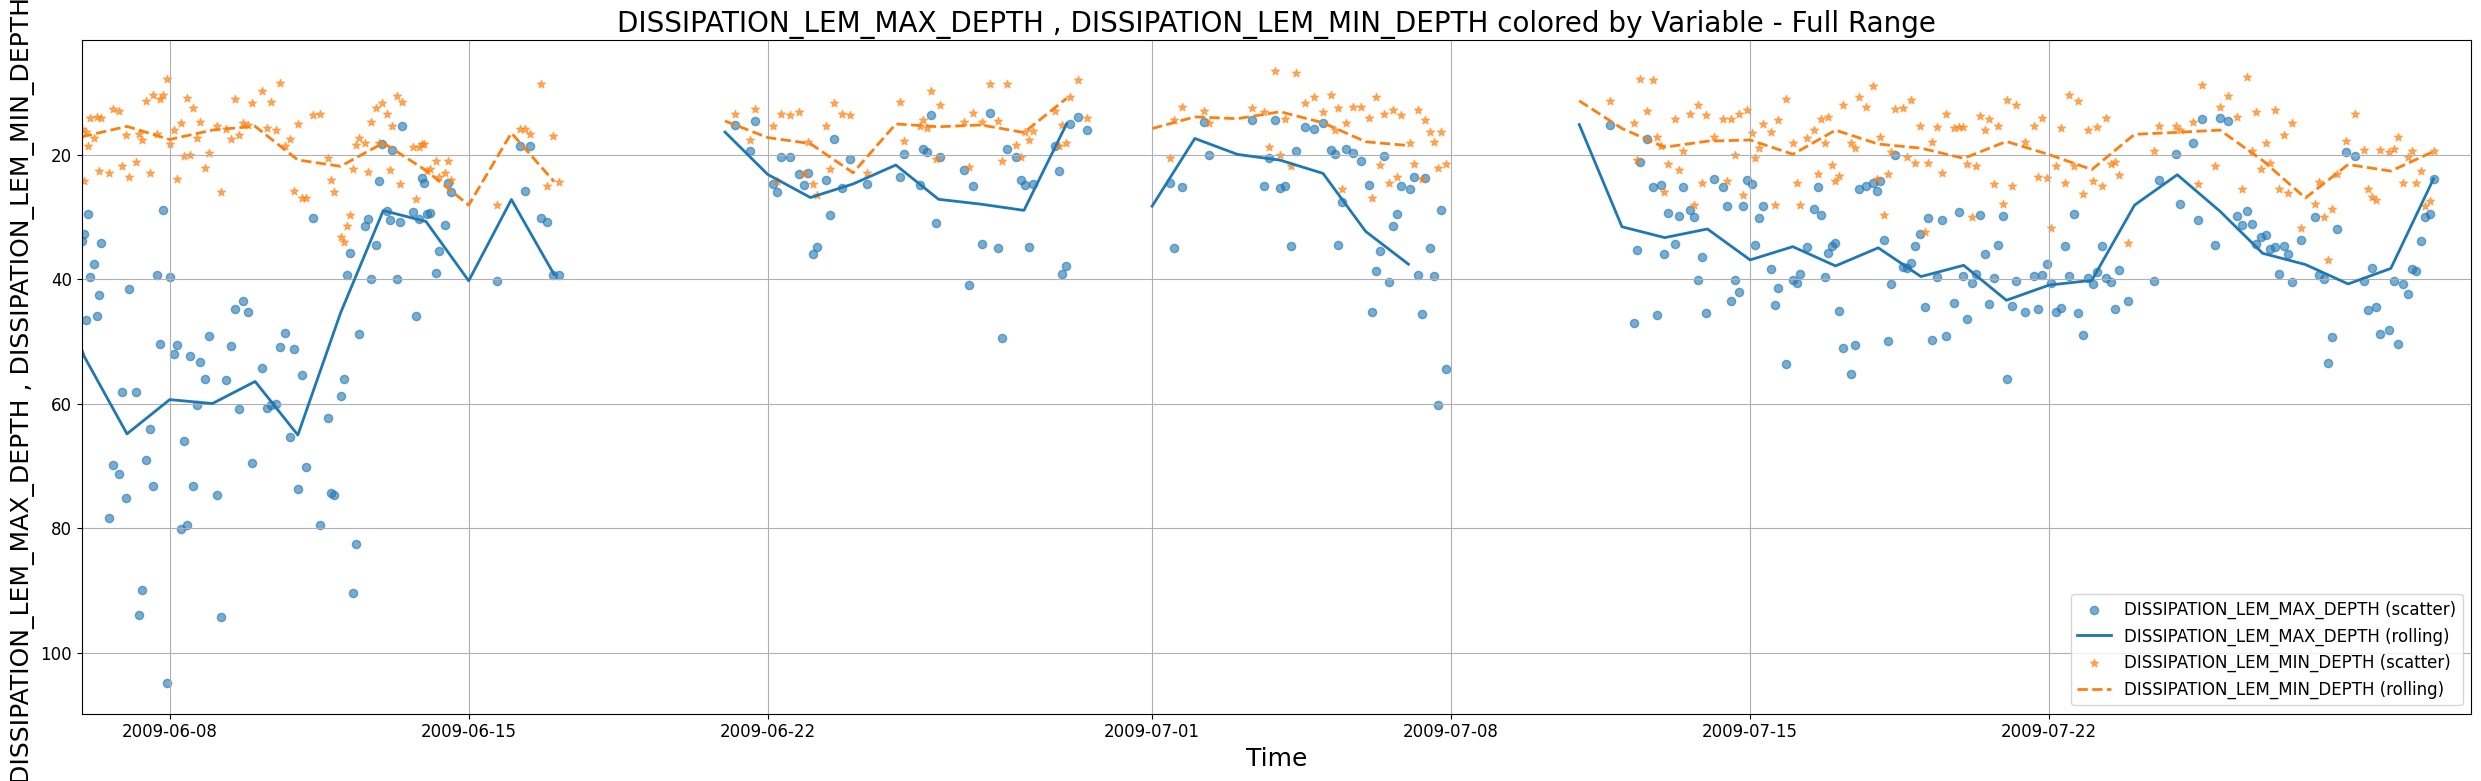

In [38]:
importlib.reload(plotting)
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['swh'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['zust'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['MLD','H_S'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
[ax.invert_yaxis() for ax in axes]
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['DISSIPATION_LEM_MAX_DEPTH','DISSIPATION_LEM_MIN_DEPTH'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
[ax.invert_yaxis() for ax in axes]
plt.show()

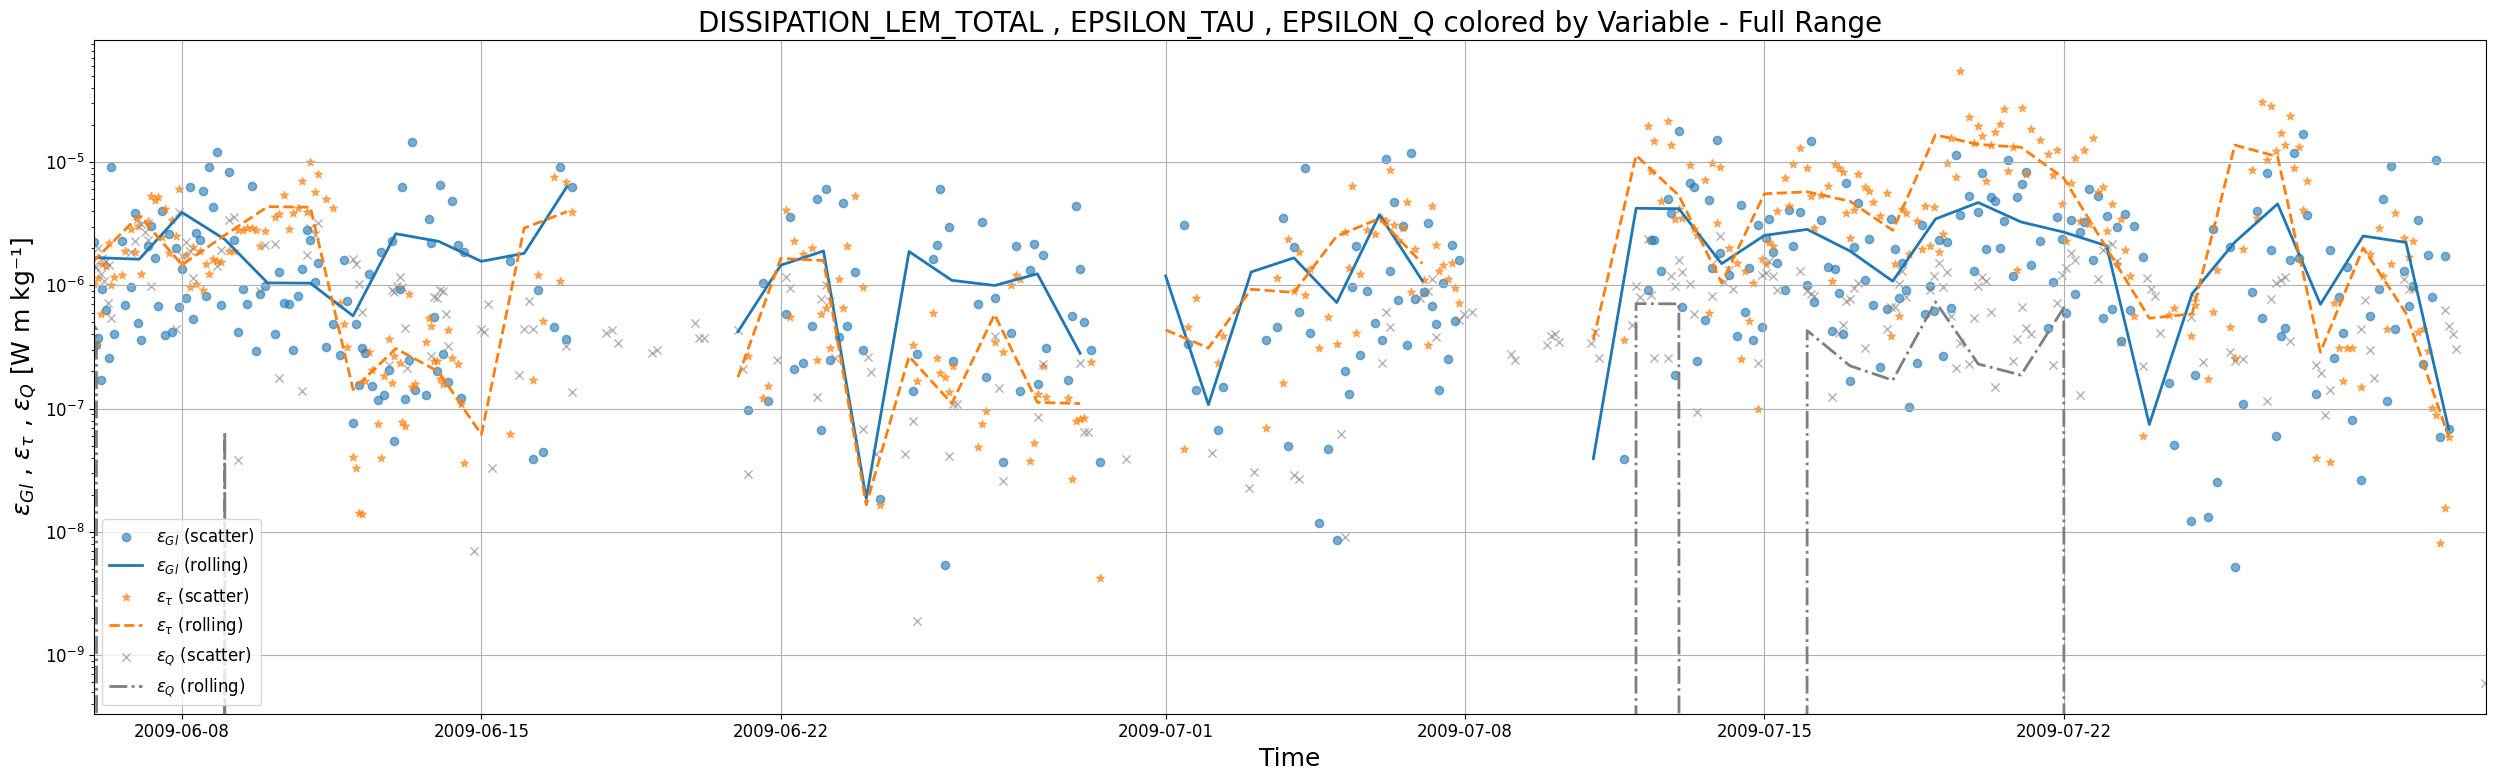

In [39]:
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['DISSIPATION_LEM_TOTAL','EPSILON_TAU','EPSILON_Q'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
### make y-axis logarithmic
[ax.set_yscale('log') for ax in axes]
fig.savefig(mission_path + '/dissipation_LEM_total_EPSILON_TAU.png', dpi=300, bbox_inches='tight')
plt.show()

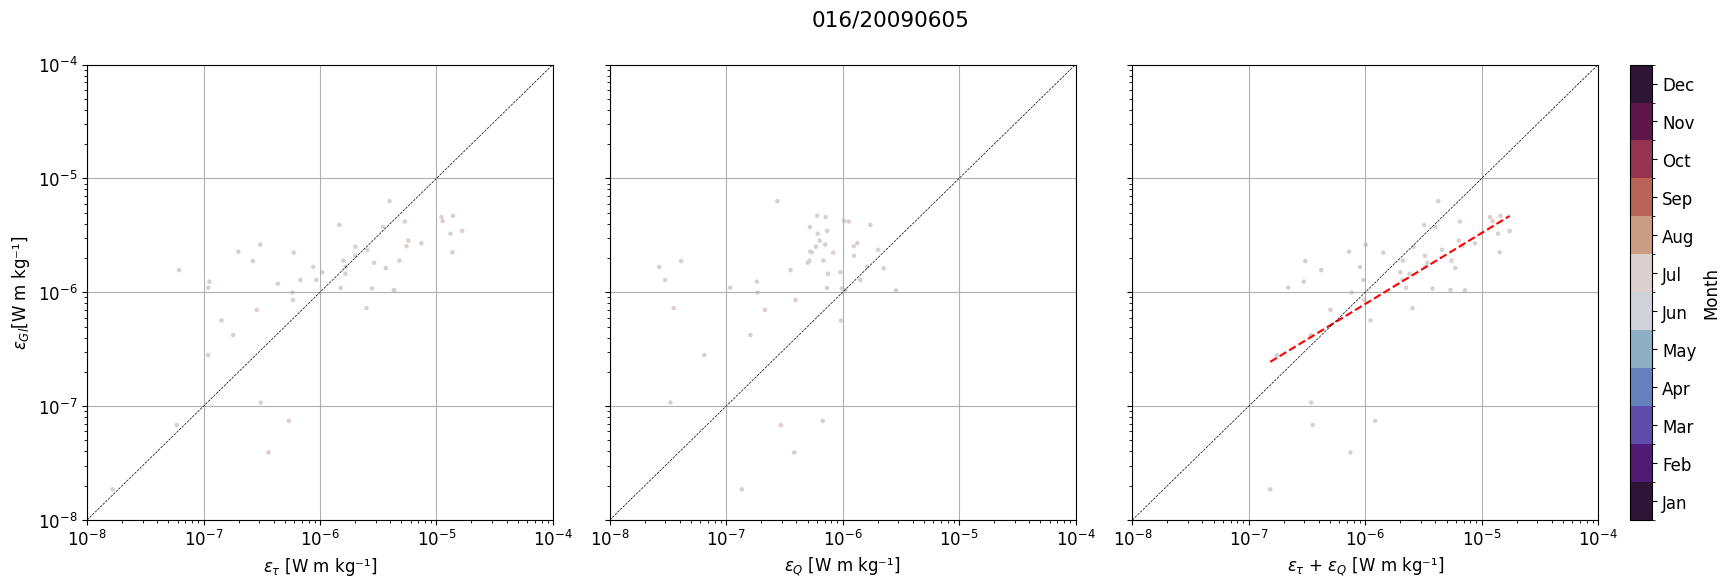

In [40]:
importlib.reload(plotting)
mld_ds['EPSILON_Q'] = mld_ds['EPSILON_Q'].where(mld_ds['EPSILON_Q'] > 0, np.nan)
fig, ax = plotting.plot_dissipation_scatter(mld_ds, rolling_str="1d", color_by='TIME')
fig.savefig(mission_path + '/dissipation_scatter.png', dpi=300, bbox_inches='tight')

## Check periods where observed dissipation is elevated compared to the calculated dissipation

In [905]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=3, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', index=2, options=('11/07 (dives: 452)', '06/08 (dives: 421)', '06/09 (…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/016/20090605/


In [1004]:
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

In [1005]:
mission_path

'/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/016/20090605'

In [1006]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')#
#mld = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)
mld = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-2, use_bins=True, binning = 5)
ds_binned = xr.open_dataset(mission_path + '/dissipation_binned.nc')
mld_ds = xr.open_dataset(mission_path + '/dissipation_mld_CR.nc')

In [1007]:
mld_ds['EPSILON_Q'] = mld_ds['EPSILON_Q'].where(mld_ds['EPSILON_Q'] > 0, np.nan)

In [1008]:
mld_ds['EPSILON_SUM'] = mld_ds['EPSILON_TAU'] + mld_ds['EPSILON_Q']

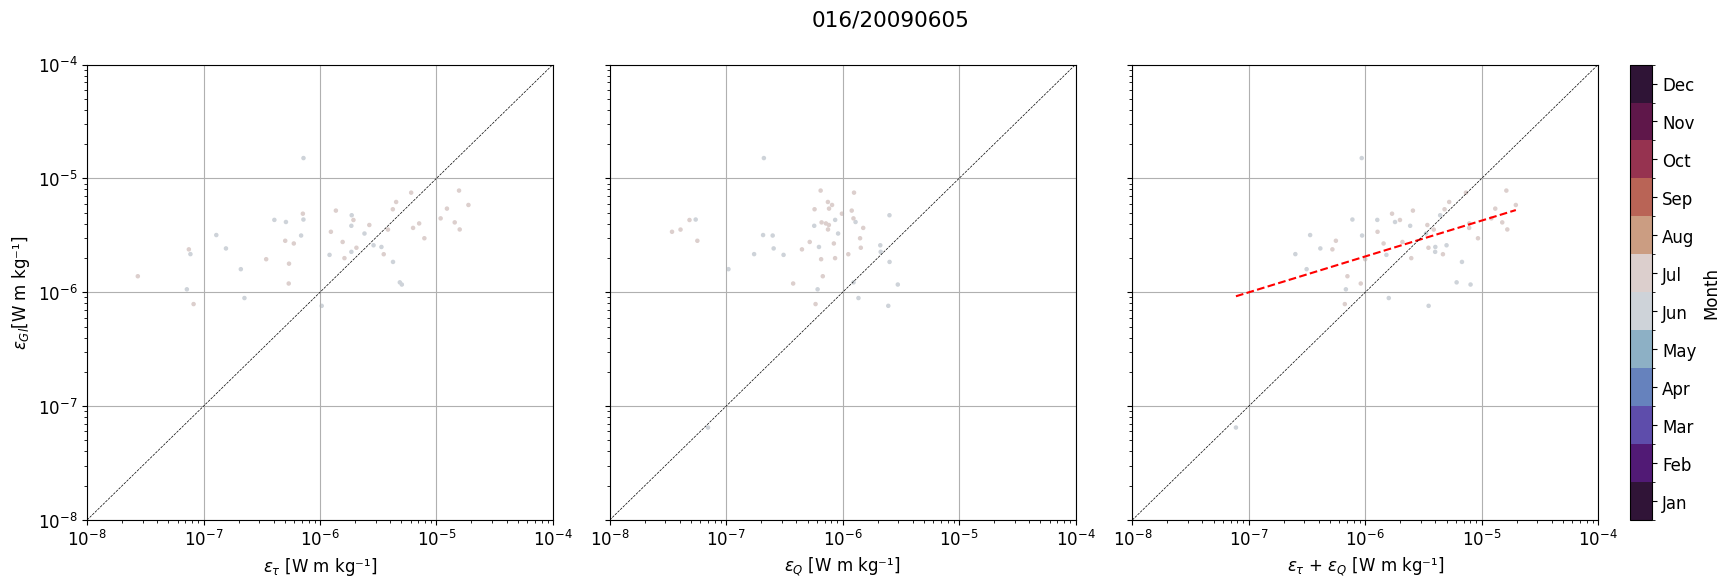

In [1009]:
importlib.reload(plotting)
rolling_str = '1D'
fig, ax = plotting.plot_dissipation_scatter(mld_ds, rolling_str=rolling_str, color_by='TIME')
#fig.savefig(mission_path + '/dissipation_scatter.png', dpi=300, bbox_inches='tight')

In [1010]:
### get all the profile numbers, where DISSIPATION_LEM_TOTAL is larger than EPSILON_SUM
ds_rolling = mld_ds.resample(TIME=rolling_str).mean(dim='TIME').sortby('TIME')

# Boolean mask: True where condition holds
cond = ds_rolling['DISSIPATION_LEM_TOTAL'] > ds_rolling['EPSILON_SUM']

# Original profile numbers
profiles = ds_rolling['PROFILE_NUMBER'].values
times = ds_rolling['TIME'].values

profiles_mid = profiles[cond.values]
times_mid = times[cond.values]

# --- Find contiguous intervals where cond == True ---
intervals = []
intervals_times = []
in_interval = False
start = None

for i in range(len(cond)):
    if cond.values[i] and not in_interval:
        # entering an interval
        start = i
        in_interval = True
    elif not cond.values[i] and in_interval:
        # leaving an interval
        end = i - 1
        # compute border as mean between just-outside profiles
        left_border = (profiles[start-1] + profiles[start]) / 2 if start > 0 else profiles[start]
        right_border = (profiles[end] + profiles[end+1]) / 2 if end+1 < len(profiles) else profiles[end]
        intervals.append((left_border, right_border))
        in_interval = False

# Handle case where condition ends at the last element
if in_interval:
    end = len(cond) - 1
    left_border = (profiles[start-1] + profiles[start]) / 2 if start > 0 else profiles[start]
    right_border = profiles[end]
    intervals.append((left_border, right_border))

intervals = np.array(intervals, dtype=object)  # array of tuples

In [1011]:
intervals

array([[np.float64(32.5), np.float64(44.0)],
       [np.float64(90.75), np.float64(119.5)],
       [np.float64(170.25), np.float64(261.75)],
       [np.float64(283.25), np.float64(313.0)],
       [np.float64(357.25), np.float64(389.25)],
       [np.float64(412.25), np.float64(422.75)],
       [np.float64(446.0), np.float64(457.5)],
       [np.float64(516.5), np.float64(536.25)],
       [np.float64(554.75), np.float64(589.0)]], dtype=object)

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:448: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dim = list(ds.dims.keys())[0]


/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:448: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dim = list(ds.dims.keys())[0]


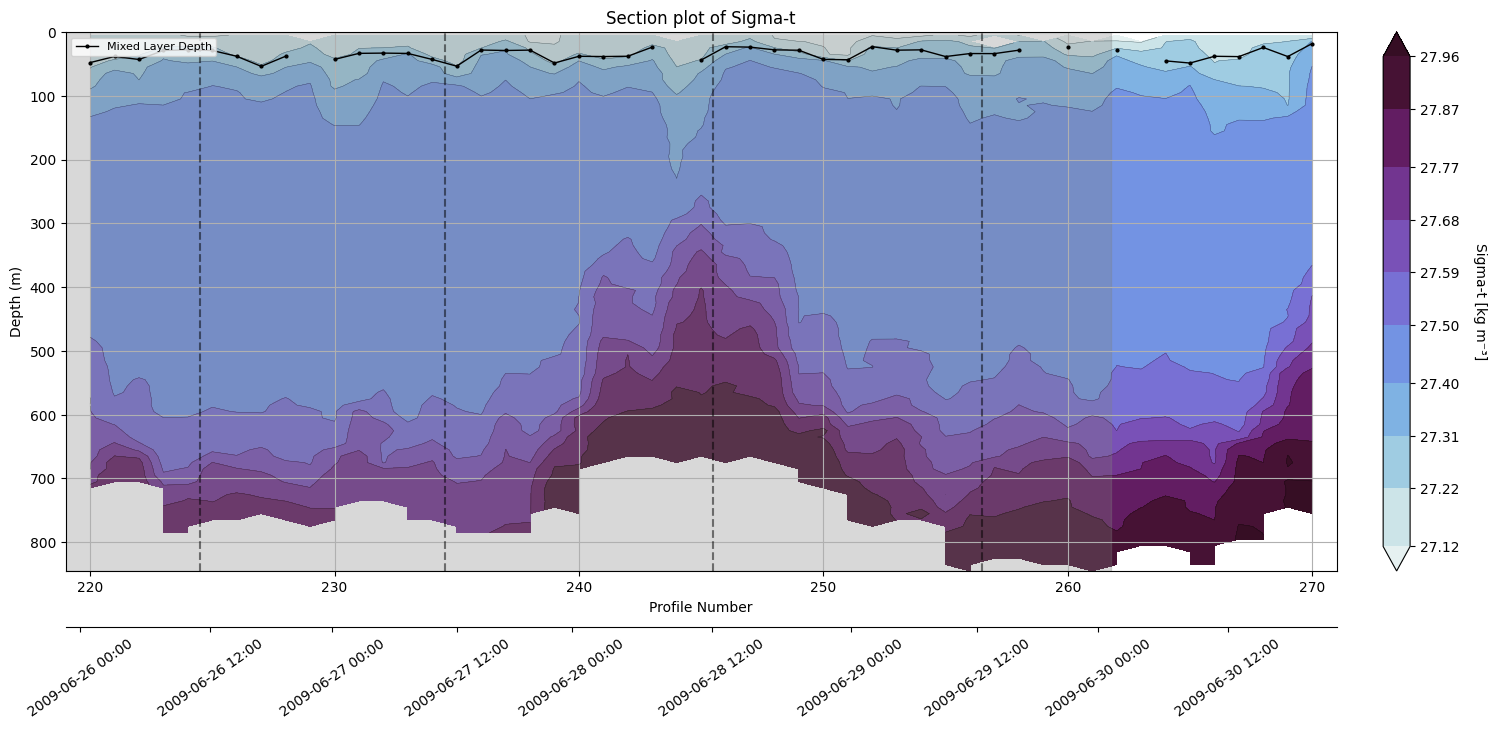

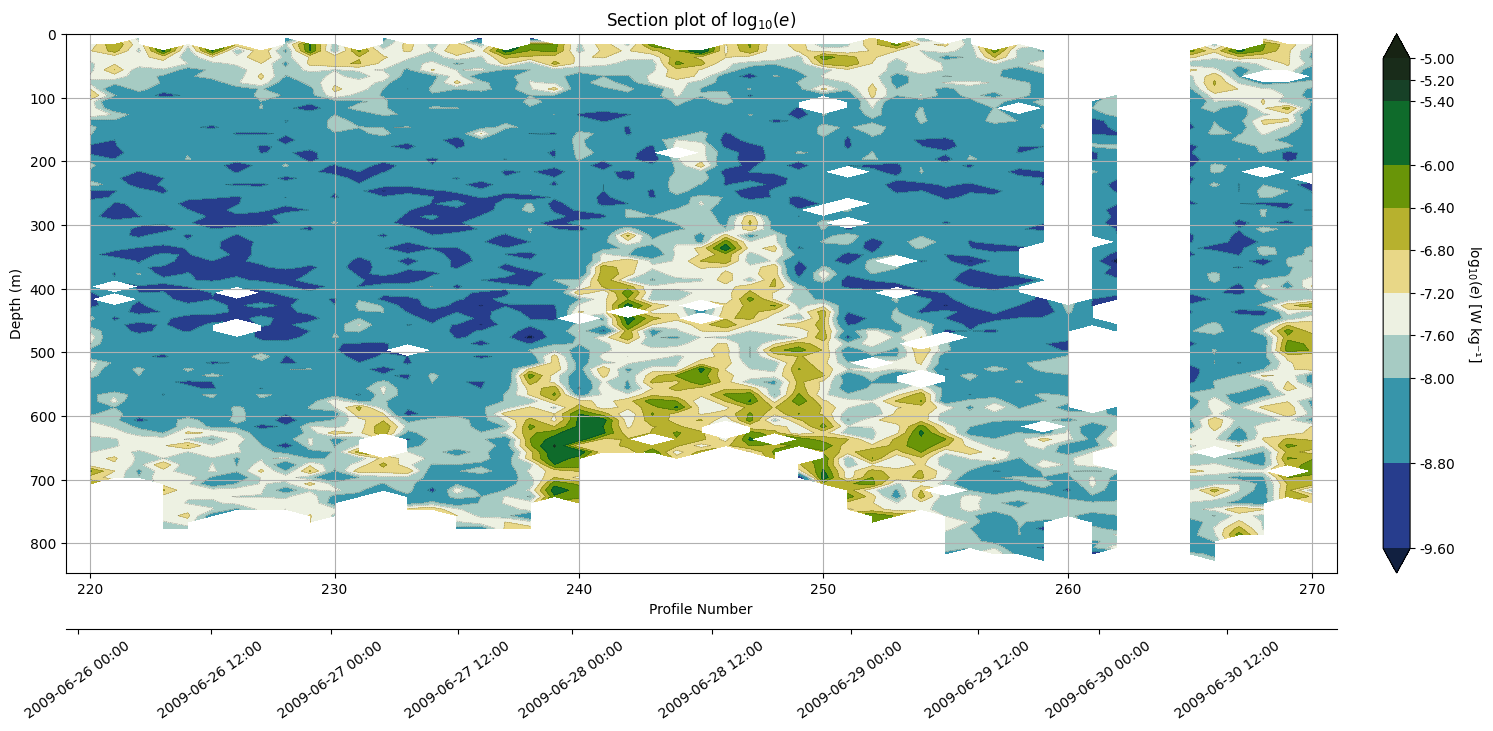

In [1012]:
### plot all the profiles as vertical lines in plot_section
start = 220
end = 270
levels = [26.9,27.1,27.3,27.4,27.5,27.6,27.7,27.8,27.9,28.0]
fig, axs = plotting.plot_section(ds, vars=['SIGMA_T'], v_res=10, levels = True, start=start, end=end, mld_df = mld)
for i in range(len(profiles_mid)):
    axs[-1].axvline(profiles_mid[i], color='black', linestyle='--', alpha=0.5)
    ### add and interval shading for each interval
for i in range(len(intervals)):
    axs[-1].axvspan(intervals[i][0], intervals[i][1], color='grey', alpha=0.3)

ylim = axs[-1].get_ylim()
axs[-1].set_ylim( ylim[0],0)

plt.savefig(mission_path + '/Elevated_observed_dissipation.png', dpi=300, bbox_inches='tight')

levels = [-9.6,-8.8,-8.0,-7.6,-7.2,-6.8,-6.4,-6.0,-5.4,-5.2,-5.0]
fig, axs = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10, levels = levels, start=start, end=end)

ylim = axs[-1].get_ylim()
axs[-1].set_ylim( ylim[0],0)
#fig, axs = plotting.plot_section(ds_binned, vars=['VELOCITY_SCALE_2_LOG','SORTED_N2_LOG'], v_res=10, levels = True, start=start, end=end)
plt.show()

In [1013]:
### print the DISSIPATION_LEM_TOTAL, value for profile number 237
profile_number = 240
dissipation_value = mld_ds['DISSIPATION_LEM_TOTAL'].where(mld_ds['PROFILE_NUMBER'] == profile_number, drop=True).values[0]
dissiaption_min = mld_ds['DISSIPATION_LEM_MIN_DEPTH'].where(mld_ds['PROFILE_NUMBER'] == profile_number, drop=True).values[0]
print(f'Profile Number: {profile_number}, DISSIPATION_LEM_TOTAL: {dissipation_value:.2e} [W/kg]', f'at depth {dissiaption_min} [m]')

Profile Number: 240, DISSIPATION_LEM_TOTAL: 6.97e-07 [W/kg] at depth 16.383042357488147 [m]


In [945]:
interactive.interactive_profile(ds_binned, mld_df=mld)

Output()